In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set a consistent style for all visualisations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [70]:
# Loading the datasets
df_sentiment = pd.read_csv('../data/raw/sentimentdataset.csv')
df_tweets = pd.read_csv('../data/raw/Tweets.csv')

In [71]:
print("=== RAW DATA LOADED ===")
print(f"sentimentdataset.csv  → {df_sentiment.shape[0]} rows, {df_sentiment.shape[1]} columns")
print(f"Tweets.csv            → {df_tweets.shape[0]} rows, {df_tweets.shape[1]} columns")

=== RAW DATA LOADED ===
sentimentdataset.csv  → 732 rows, 15 columns
Tweets.csv            → 14640 rows, 15 columns


In [72]:
print("\nsentimentdataset.csv columns:", df_sentiment.columns.tolist())
print("Tweets.csv columns:", df_tweets.columns.tolist())
 


sentimentdataset.csv columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
Tweets.csv columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


#### ================================================================
#### STEP 1: DROP USELESS COLUMNS — KEEP ONLY text + sentiment
#### ================================================================
 sentimentdataset.csv has 15 columns — we only need Text and Sentiment.

 Tweets.csv has 15 columns — we only need text and airline_sentiment. 
 
 Everything else (timestamps, user IDs, locations etc.) is irrelevant
 for training a sentiment model

In [73]:
df_sentiment = df_sentiment[['Text', 'Sentiment']]
df_tweets = df_tweets[['text', 'airline_sentiment']]

In [74]:
# Rename columns to a consistent standard across both datasets
df_sentiment = df_sentiment.rename(columns={'Text': 'text', 'Sentiment': 'sentiment'})
df_tweets = df_tweets.rename(columns={'airline_sentiment': 'sentiment'})


print("\n=== AFTER DROPPING USELESS COLUMNS ===")
print(f"df_sentiment columns: {df_sentiment.columns.tolist()}")
print(f"df_tweets columns: {df_tweets.columns.tolist()}")


=== AFTER DROPPING USELESS COLUMNS ===
df_sentiment columns: ['text', 'sentiment']
df_tweets columns: ['text', 'sentiment']


In [75]:
print("\n=== NULL VALUES CHECK ===")
print("df_sentiment nulls:\n", df_sentiment.isnull().sum())
print("\ndf_tweets nulls:\n", df_tweets.isnull().sum())


# no null values returned so no need for dropping nas or filling them in
 


=== NULL VALUES CHECK ===
df_sentiment nulls:
 text         0
sentiment    0
dtype: int64

df_tweets nulls:
 text         0
sentiment    0
dtype: int64


In [76]:
# drop rows where text is just whitespace or empty string
df_sentiment = df_sentiment[df_sentiment['text'].str.strip().str.len() > 0]
df_tweets = df_tweets[df_tweets['text'].str.strip().str.len() > 0]


In [77]:
def normalize_label(label):
    """
    Maps any sentiment label to one of three standard classes:
    Positive, Negative, or Neutral.
    Returns None for labels we cannot confidently map.
    """
    label = str(label).strip().lower()
 
    positive_labels = [
        'positive', 'joy', 'happiness', 'happy', 'love', 'excitement',
        'excited', 'contentment', 'content', 'gratitude', 'grateful',
        'serenity', 'serene', 'hopeful', 'hope', 'awe', 'pride',
        'acceptance', 'relief', 'mischievous', 'enthusiasm'
    ]
 
    negative_labels = [
        'negative', 'anger', 'angry', 'fear', 'sadness', 'sad',
        'disgust', 'disgusted', 'grief', 'despair', 'loneliness',
        'lonely', 'embarrassed', 'embarrassment', 'hate', 'bad',
        'nostalgia', 'confusion', 'confused', 'anxiety', 'anxious'
    ]
 
    neutral_labels = [
        'neutral', 'curiosity', 'curious', 'surprise', 'surprised'
    ]
 
    if label in positive_labels:
        return 'Positive'
    elif label in negative_labels:
        return 'Negative'
    elif label in neutral_labels:
        return 'Neutral'
    else:
        # Any label we cannot confidently classify is dropped
        return None
 

In [78]:
# Apply normalisation to both datasets
df_sentiment['sentiment'] = df_sentiment['sentiment'].apply(normalize_label)
df_tweets['sentiment'] = df_tweets['sentiment'].apply(normalize_label)


 

In [79]:
# Drop rows where the label could not be mapped
before_sentiment = len(df_sentiment)
before_tweets = len(df_tweets)
 
df_sentiment = df_sentiment.dropna(subset=['sentiment'])
df_tweets = df_tweets.dropna(subset=['sentiment'])
 
print("\n=== LABEL NORMALISATION ===")
print(f"df_sentiment: {before_sentiment} → {len(df_sentiment)} rows (dropped {before_sentiment - len(df_sentiment)} unmappable labels)")
print(f"df_tweets: {before_tweets} → {len(df_tweets)} rows (dropped {before_tweets - len(df_tweets)} unmappable labels)")
 
print("\ndf_sentiment label distribution after normalisation:")
print(df_sentiment['sentiment'].value_counts())
 
print("\ndf_tweets label distribution after normalisation:")
print(df_tweets['sentiment'].value_counts())
 
 


=== LABEL NORMALISATION ===
df_sentiment: 732 → 386 rows (dropped 346 unmappable labels)
df_tweets: 14640 → 14640 rows (dropped 0 unmappable labels)

df_sentiment label distribution after normalisation:
sentiment
Positive    252
Negative     94
Neutral      40
Name: count, dtype: int64

df_tweets label distribution after normalisation:
sentiment
Negative    9178
Neutral     3099
Positive    2363
Name: count, dtype: int64


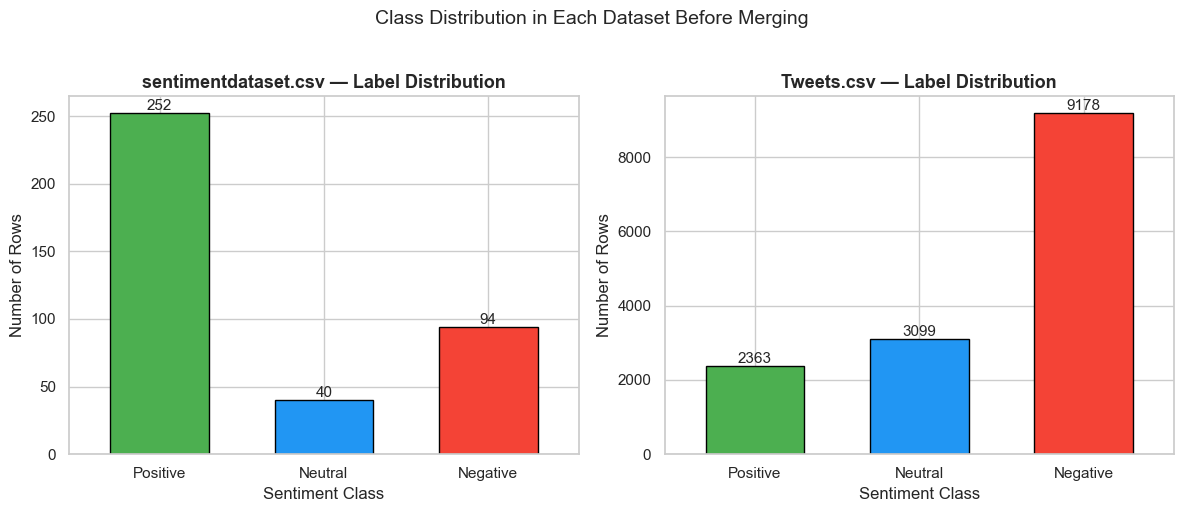

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Keep the same class order and colors across both plots
sentiment_order = ['Positive', 'Neutral', 'Negative']
sentiment_colors = {
    'Positive': '#4CAF50',
    'Neutral': '#2196F3',
    'Negative': '#F44336'
}
bar_colors = [sentiment_colors[s] for s in sentiment_order]

# Dataset 1
df_sentiment['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).plot(
    kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', width=0.6
)
axes[0].set_title('sentimentdataset.csv — Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Rows')
axes[0].tick_params(axis='x', rotation=0)

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Dataset 2
df_tweets['sentiment'].value_counts().reindex(sentiment_order, fill_value=0).plot(
    kind='bar', ax=axes[1], color=bar_colors, edgecolor='black', width=0.6
)
axes[1].set_title('Tweets.csv — Label Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Number of Rows')
axes[1].tick_params(axis='x', rotation=0)

for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.suptitle('Class Distribution in Each Dataset Before Merging', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('viz1_distribution_before_merge.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
# REMOVE DUPLICATES WITHIN EACH DATASET

print("\n=== DUPLICATES CHECK (BEFORE REMOVAL) ===")
print(f"df_sentiment duplicates: {df_sentiment.duplicated(subset='text').sum()}")
print(f"df_tweets duplicates: {df_tweets.duplicated(subset='text').sum()}")



df_sentiment = df_sentiment.drop_duplicates(subset='text')
df_tweets = df_tweets.drop_duplicates(subset='text')


print("\nAfter removing duplicates within each dataset:")
print(f"df_sentiment → {df_sentiment.shape[0]} rows")
print(f"df_tweets → {df_tweets.shape[0]} rows")


=== DUPLICATES CHECK (BEFORE REMOVAL) ===
df_sentiment duplicates: 8
df_tweets duplicates: 213

After removing duplicates within each dataset:
df_sentiment → 378 rows
df_tweets → 14427 rows


In [82]:
# MERGE THE TWO DATASETS

df_sentiment['source'] = 'social_media'
df_tweets['source'] = 'airline_tweets'

combined_df = pd.concat([df_sentiment, df_tweets], ignore_index=True)

In [84]:
print("\n=== AFTER MERGING ===")
print(f"Combined dataset → {combined_df.shape[0]} rows")
print("\nSource breakdown:")
print(combined_df['source'].value_counts())


=== AFTER MERGING ===
Combined dataset → 14805 rows

Source breakdown:
source
airline_tweets    14427
social_media        378
Name: count, dtype: int64
